In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Carregar o arquivo Excel com todas as abas (sheet_name=None carrega um dicionário de DataFrames)
# ATENÇÃO: Substitua pelo nome exato do seu arquivo
arquivo_excel = '../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
abas_excel = pd.read_excel(arquivo_excel, sheet_name=None)

# Extraindo os anos
df_2022 = abas_excel.get('PEDE2022')
df_2023 = abas_excel.get('PEDE2023')
df_2024 = abas_excel.get('PEDE2024')

print(f"Linhas 2022: {df_2022.shape[0]} | Linhas 2023: {df_2023.shape[0]} | Linhas 2024: {df_2024.shape[0]}")

Linhas 2022: 860 | Linhas 2023: 1014 | Linhas 2024: 1156


---
## Padronização de Colunas


In [10]:
# Padronizando 2022
colunas_2022 = {
    'Idade 22': 'Idade', 
    'Matem': 'Mat', 
    'Portug': 'Por', 
    'Inglês': 'Ing', 
    'Defas': 'Defasagem'
}
df_2022 = df_2022.rename(columns=colunas_2022)

# Lista de indicadores e variáveis importantes que existem (ou deveriam existir) em todos os anos
colunas_interesse = [
    'RA', 'Fase', 'Idade', 'Ano ingresso', 
    'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 
    'Mat', 'Por', 'Defasagem'
]

# Selecionando apenas as colunas de interesse em cada ano
df_22_filtrado = df_2022[[c for c in colunas_interesse if c in df_2022.columns]].copy()
df_23_filtrado = df_2023[[c for c in colunas_interesse if c in df_2023.columns]].copy()
df_24_filtrado = df_2024[[c for c in colunas_interesse if c in df_2024.columns]].copy()

# Criando uma coluna de "Ano" para não misturar temporalmente
df_22_filtrado['Ano_Referencia'] = 2022
df_23_filtrado['Ano_Referencia'] = 2023
df_24_filtrado['Ano_Referencia'] = 2024

# Unindo tudo em um único Dataset histórico
df_full = pd.concat([df_22_filtrado, df_23_filtrado, df_24_filtrado], ignore_index=True)
print("Base consolidada pronta! Formato:", df_full.shape)

Base consolidada pronta! Formato: (3030, 14)


---
## Célula 3: Limpeza de Dados e Criação do "Target" (Alvo)

In [11]:
# Tratamento de Nulos (preenchendo notas vazias com a mediana)
cols_numericas = ['Idade', 'Ano ingresso', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Mat', 'Por']
for col in cols_numericas:
    if col in df_full.columns:
        # Usamos mediana por ser imune a outliers
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce') # Garante que tudo é número
        df_full[col] = df_full[col].fillna(df_full[col].median())

# Criando a variável Target (Nosso Risco de Defasagem)
df_full['TARGET_RISCO'] = df_full['Defasagem'].apply(lambda x: 1 if x < 0 else 0)

# Verificando a distribuição (Quantos alunos em risco vs adequados)
print(df_full['TARGET_RISCO'].value_counts(normalize=True) * 100)

TARGET_RISCO
1    55.676568
0    44.323432
Name: proportion, dtype: float64


---
## Célula 4: Análise Exploratória (EDA)

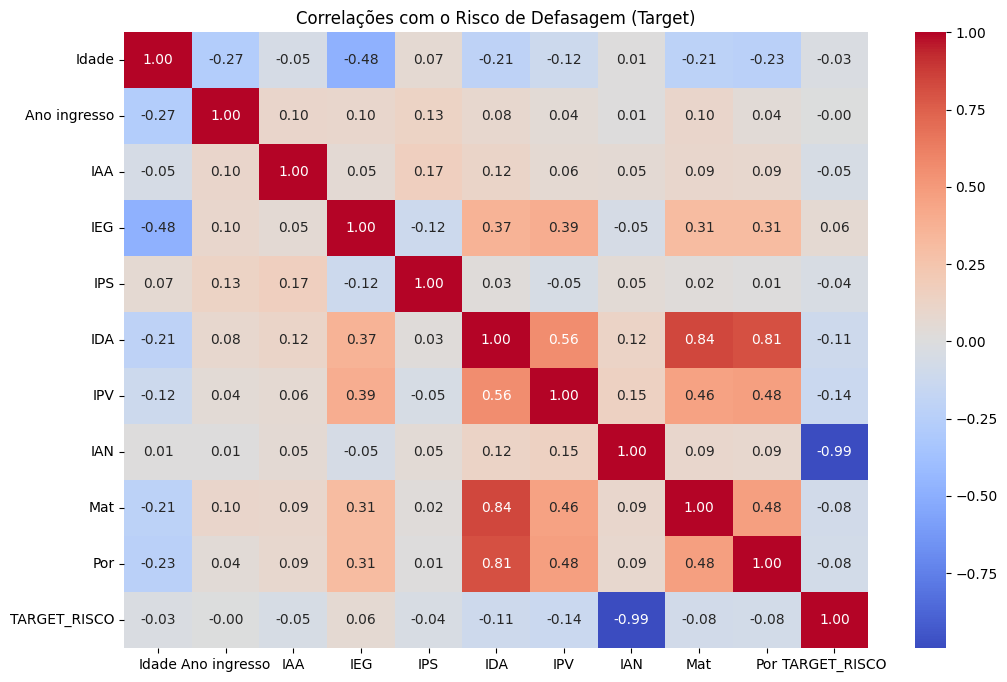

/tmp/ipykernel_23392/854864184.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET_RISCO', data=df_full, palette='Set2')


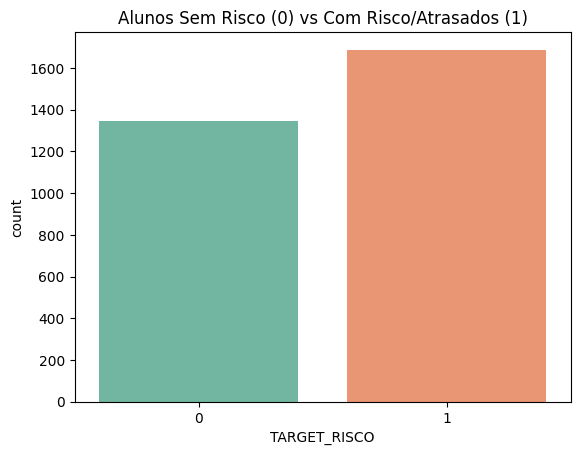

In [12]:
# Analisando a correlação das features numéricas com o Risco de Defasagem
correlacoes = df_full[cols_numericas + ['TARGET_RISCO']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlações com o Risco de Defasagem (Target)')
plt.show()

# Gráfico para visualização rápida da Target
sns.countplot(x='TARGET_RISCO', data=df_full, palette='Set2')
plt.title('Alunos Sem Risco (0) vs Com Risco/Atrasados (1)')
plt.show()

## Célula 5: Divisão e Treinamento do Modelo Preditivo

Acurácia Global: 0.6996699669966997

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.69      0.60      0.64       269
           1       0.71      0.78      0.74       337

    accuracy                           0.70       606
   macro avg       0.70      0.69      0.69       606
weighted avg       0.70      0.70      0.70       606



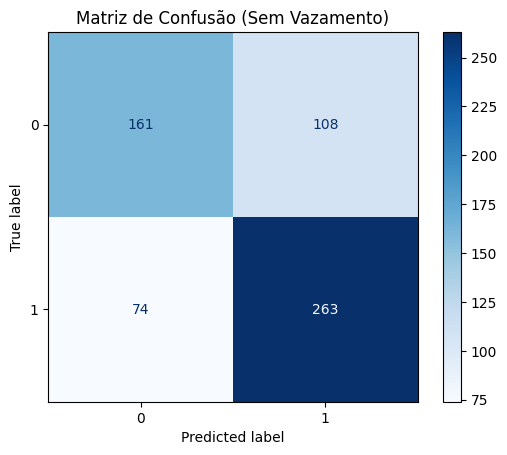

In [13]:
# 1. Removendo o IAN para evitar o Data Leakage (Vazamento de Dados)
# Também garantimos que 'Defasagem' e 'TARGET_RISCO' não entrem no X
features_seguras = ['Idade', 'Ano ingresso', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'Mat', 'Por']

X = df_full[features_seguras]
y = df_full['TARGET_RISCO']

# 2. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Treinamento do Modelo CORRIGIDO
# class_weight='balanced' resolve o problema do modelo chutar "tudo 1" ou "tudo 0"
rf_model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced' # <--- O segredo para não colapsar em uma classe só
)

rf_model.fit(X_train, y_train)

# 4. Fazendo as predições
y_pred = rf_model.predict(X_test)

# 5. Avaliação Realista
print("Acurácia Global:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Vamos ver a Matriz de Confusão para ter certeza que ele não está chutando "tudo 1"
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Matriz de Confusão (Sem Vazamento)')
plt.show()

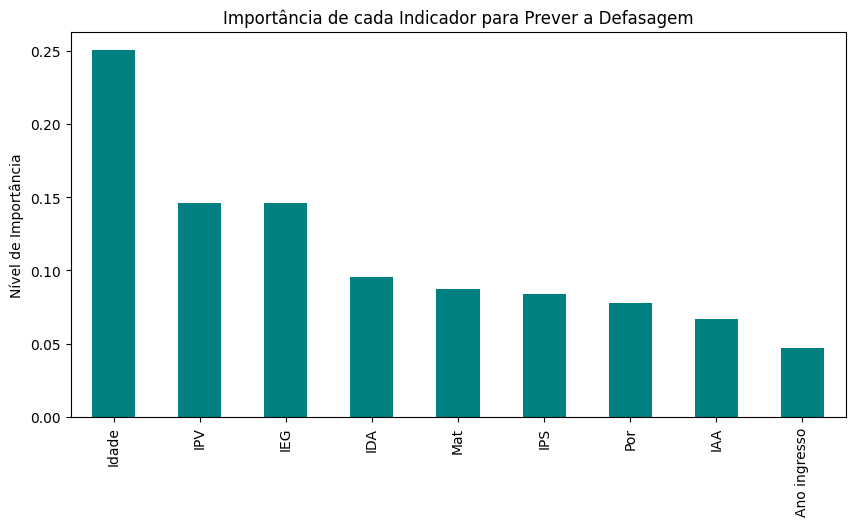

Modelo salvo como 'modelo_risco_defasagem.joblib'. Pronto para deploy na API!


In [15]:
# Descobrindo quais indicadores o modelo acha mais importantes
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='teal')
plt.title('Importância de cada Indicador para Prever a Defasagem')
plt.ylabel('Nível de Importância')
plt.show()

# Salvando o modelo na máquina (Para criar a API na etapa seguinte do trabalho)
joblib.dump(rf_model, 'modelo_risco_defasagem.joblib')
print("Modelo salvo como 'modelo_risco_defasagem.joblib'. Pronto para deploy na API!")